In [1]:
# Imports block
from pathlib import Path
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
from rasterio import open as rio_open
from rasterio.mask import mask
from shapely.geometry import box, shape

import pickle

from ra2ce.network.network_config_data.enums.aggregate_wl_enum import AggregateWlEnum
from ra2ce.network.network_config_data.enums.source_enum import SourceEnum
from ra2ce.network.network_config_data.enums.network_type_enum import NetworkTypeEnum
from ra2ce.network.network_config_data.enums.road_type_enum import RoadTypeEnum
from ra2ce.network.network_config_data.network_config_data import (
    HazardSection,
    NetworkConfigData,
    NetworkSection,
)
from ra2ce.ra2ce_handler import Ra2ceHandler

cwd_path = Path.cwd()   
repo_path = cwd_path.parent.parent

print('repo_path:', repo_path)

sys.path.append(str(repo_path))

c:\Users\meije_le\AppData\Local\miniforge3\envs\ra2ce_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


repo_path: c:\python\powerpath


In [2]:
# Support function definitions

def get_all_files(directory: str) -> list[Path]:
    p = Path(directory)
    return [file for file in p.iterdir() if file.is_file()]

def read_pickle(file_path: str):
    with open(file_path, 'rb') as file:
        data = pickle.load(file)
    return data

def read_gpkg_to_gdf(file_path: str, layer: str = None) -> gpd.GeoDataFrame:
    # Read the geopackage file into a GeoDataFrame
    gdf = gpd.read_file(file_path, layer=layer)
    return gdf


In [ ]:
# Define paths
src_data_folder_name = 'ZH_Delfland'
dest_data_folder_name = 'N:\Projects\11209000\11209175\B. Measurements and calculations\Data'
src_data_path = Path(rf'C:\repos\powerpath\raw_data\{src_data_folder_name}')
dest_data_path = Path(rf'C:\repos\powerpath\data\{dest_data_folder_name}')
local_data_path = Path('C:/data')

directory_dictionary = {
    "root_dir": dest_data_path,
    "static_path": dest_data_path.joinpath("static"),
    "network_path": dest_data_path.joinpath("static", "network"),
    "output_path": dest_data_path.joinpath("static", "output_graph"),
    "electricity_dir": dest_data_path.joinpath("electricity"),
    "hazard_files_dir": dest_data_path.joinpath(f"test_hazard_timesteps"),
    "hazard_files_src_dir": src_data_path.joinpath(f"hazard_maps_{src_data_folder_name}"),
}

# Make sure all of the directories exist
for dir_path in directory_dictionary.values():
    dir_path.mkdir(parents=True, exist_ok=True)

# List files in hazard_files_dir and select the first that doesn't contain 'blank'
hazard_files = [f for f in directory_dictionary["hazard_files_src_dir"].glob("*.tif") if 'blank' not in f.name]
hazard_map_path = hazard_files[0] if hazard_files else None
assert hazard_map_path.exists(), f"Path {hazard_map_path} does not exist"

# Define path to clipping extent shapefile
clipping_extent_path = dest_data_path.joinpath("clipping", "clipping_extent.shp")

# Define paths to raw data that will be clipped
ls_station_path = local_data_path.joinpath("raw", "StedinData", "Laagspanningsstations")
msls_station_path = local_data_path.joinpath("raw", "StedinData", "MiddenLaagspanningsstations")
ms_station_path = local_data_path.joinpath("raw", "StedinData", "Middenspanningsstations")

ls_lines_path = local_data_path.joinpath("raw", "StedinData", "Laagspanningsverbindingen")
ms_lines_path = local_data_path.joinpath("raw", "StedinData", "Middenspanningsverbindingen")

raw_paths = [ls_station_path,msls_station_path,ms_station_path, 
             ls_lines_path, ms_lines_path]

for path in raw_paths:
    assert path.exists(), f"Path {path} does not exist"


In [ ]:
# If clipping_extent_path exists: clip the raster files and save to destination folder
name_override = 'GHG_timesteps_test'

if clipping_extent_path.exists():
    # Read the clipping extent
    clipping_extent = gpd.read_file(clipping_extent_path)
    clipping_geometry = [shape(geom) for geom in clipping_extent.geometry]

    for i, haz_map in enumerate(hazard_files):
        with rio_open(haz_map) as src:
            # Reproject clipping geometry if CRS does not match
            if src.crs != clipping_extent.crs:
                clipping_extent_proj = clipping_extent.to_crs(src.crs)
                clipping_geometry_proj = [shape(geom) for geom in clipping_extent_proj.geometry]
            else:
                clipping_geometry_proj = clipping_geometry

            # Clip the hazard map
            out_image, out_transform = mask(src, clipping_geometry_proj, crop=True)
            out_meta = src.meta.copy()
            out_meta.update({
                "driver": "GTiff",
                "height": out_image.shape[1],
                "width": out_image.shape[2],
                "transform": out_transform
            })

            # Save the clipped raster to the destination folder
            if name_override:
                file_name = name_override + str(i+1) + haz_map.suffix
                clipped_hazard_map_path = directory_dictionary["hazard_files_dir"].joinpath(file_name)
            else:
                clipped_hazard_map_path = directory_dictionary["hazard_files_dir"].joinpath(haz_map.name)
            with rio_open(clipped_hazard_map_path, "w", **out_meta) as dest:
                dest.write(out_image)

            print(f"Clipped hazard map saved to {clipped_hazard_map_path}")
    



Clipped hazard map saved to C:\repos\powerpath\data\test_samples\test_hazard_timesteps\GHG_timesteps_test1.tif
Clipped hazard map saved to C:\repos\powerpath\data\test_samples\test_hazard_timesteps\GHG_timesteps_test2.tif
Clipped hazard map saved to C:\repos\powerpath\data\test_samples\test_hazard_timesteps\GHG_timesteps_test3.tif
Clipped hazard map saved to C:\repos\powerpath\data\test_samples\test_hazard_timesteps\GHG_timesteps_test4.tif
Clipped hazard map saved to C:\repos\powerpath\data\test_samples\test_hazard_timesteps\GHG_timesteps_test5.tif


Hazard map CRS: EPSG:4326


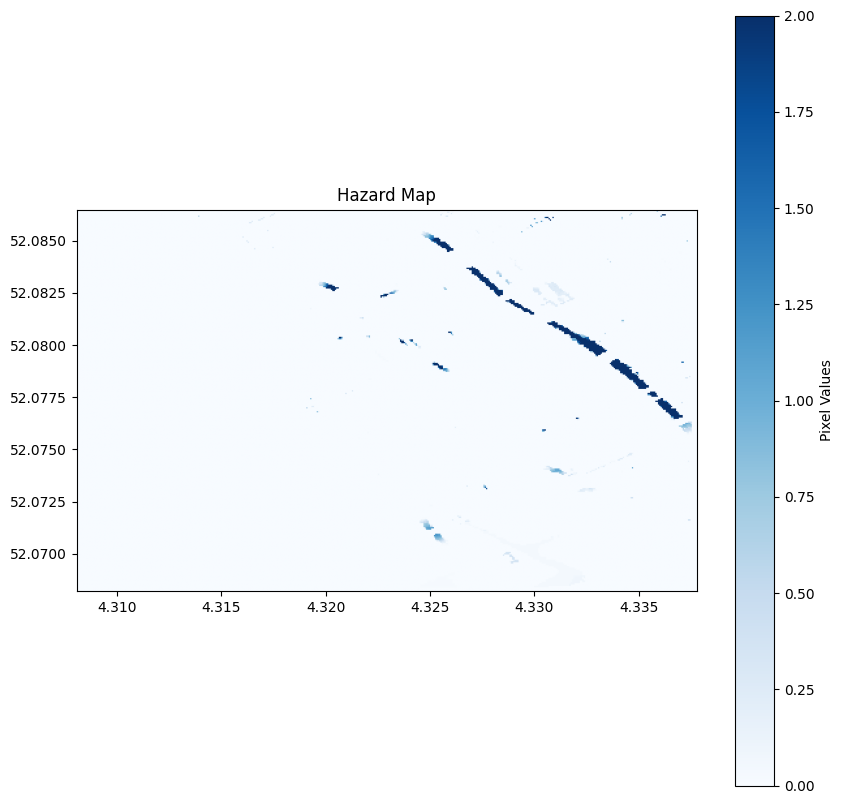

In [ ]:
# find bounding box of hazard map
with rio_open(clipped_hazard_map_path) as src:
    hazard_map = src.read(1)
    hazard_transform = src.transform
    hazard_crs = src.crs
    bounding_box_haz = box(*src.bounds)
    print(f"Hazard map CRS: {hazard_crs}")


# plot the hazard map
plt.figure(figsize=(10, 10))

# Calculate extent from transform for correct georeferencing
left, bottom = hazard_transform * (0, hazard_map.shape[0])
right, top = hazard_transform * (hazard_map.shape[1], 0)
plt.imshow(hazard_map, extent=[left, right, bottom, top], cmap='Blues', vmin=0, vmax=2)
plt.colorbar(label='Pixel Values')
plt.title('Hazard Map')
plt.show()


In [ ]:
# Buffer bounding box for the hazard by 5% to extract road network
haz_xmin, haz_ymin, haz_xmax, haz_ymax = bounding_box_haz.bounds
haz_xmin -= (haz_xmax - haz_xmin) * 0.05
haz_xmax += (haz_xmax - haz_xmin) * 0.05
haz_ymin -= (haz_ymax - haz_ymin) * 0.05
haz_ymax += (haz_ymax - haz_ymin) * 0.05
bounding_box_haz_buffered = box(haz_xmin, haz_ymin, haz_xmax, haz_ymax)
simulation_bounding_box_gdf = gpd.GeoDataFrame(geometry=[bounding_box_haz_buffered], crs=hazard_crs)
Extent_path = dest_data_path.joinpath('static', 'network', 'extent.shp')
Extent_path.parent.mkdir(parents=True, exist_ok=True)  # Ensure the directory exists
simulation_bounding_box_gdf.to_file(Extent_path, driver='ESRI Shapefile',)

<class 'shapely.geometry.polygon.Polygon'>


In [ ]:
# Load the shapefiles and clip to the bounding box
ls_stations = gpd.read_file(ls_station_path/'Laagspanningsstations.shp')
ls_stations = ls_stations.to_crs(simulation_bounding_box_gdf.crs)  # Ensure CRS matches
ls_stations = ls_stations.clip(simulation_bounding_box_gdf)
msls_stations = gpd.read_file(msls_station_path/'MiddenLaagspanningsstations.shp')
msls_stations = msls_stations.to_crs(simulation_bounding_box_gdf.crs)
msls_stations = msls_stations.clip(simulation_bounding_box_gdf)
ms_stations = gpd.read_file(ms_station_path/'Middenspanningsstations.shp')
ms_stations = ms_stations.to_crs(simulation_bounding_box_gdf.crs)  # Ensure CRS matches
ms_stations = ms_stations.clip(simulation_bounding_box_gdf)

In [ ]:
# Save to destination data folder
ls_stations.to_file(directory_dictionary["electricity_dir"]/f'ls_stations_{dest_data_folder_name}.shp')
msls_stations.to_file(directory_dictionary["electricity_dir"]/f'msls_stations_{dest_data_folder_name}.shp')
ms_stations.to_file(directory_dictionary["electricity_dir"]/f'ms_stations_{dest_data_folder_name}.shp')

In [24]:
shapely_polygon = bounding_box_haz_buffered

In [26]:
hazard_files = get_all_files(directory_dictionary["hazard_files_dir"])

# Open the first hazard file to get the crs
with rasterio.open(hazard_files[0]) as src:
    hazard_crs = src.crs
    print(f"Hazard CRS: {hazard_crs}")

# hazard_crs = "EPSG:4326" # for the hackathon case => "EPSG:4326" 


hazard_files = [f for f in hazard_files if not 'blank' in f.name and f.name.endswith('.tif')]

hazard_files = sorted(hazard_files, key=lambda x: x.name)

for hazard_file in hazard_files:
    print (hazard_file)



Hazard CRS: EPSG:4326
C:\repos\powerpath\data\test_samples\test_hazard_timesteps\GHG_timesteps_test1.tif
C:\repos\powerpath\data\test_samples\test_hazard_timesteps\GHG_timesteps_test2.tif
C:\repos\powerpath\data\test_samples\test_hazard_timesteps\GHG_timesteps_test3.tif
C:\repos\powerpath\data\test_samples\test_hazard_timesteps\GHG_timesteps_test4.tif
C:\repos\powerpath\data\test_samples\test_hazard_timesteps\GHG_timesteps_test5.tif


In [ ]:
### Let us first initalize and perform the ra2ce run so we have all the data that we need
_network_section = NetworkSection(
    network_type=NetworkTypeEnum.DRIVE,
    source=SourceEnum.OSM_DOWNLOAD,
    polygon=Extent_path, #it needs a path without the list!
    save_gpkg=True,
    road_types=[RoadTypeEnum.MOTORWAY, RoadTypeEnum.MOTORWAY_LINK, RoadTypeEnum.PRIMARY, RoadTypeEnum.PRIMARY_LINK,RoadTypeEnum.TRUNK, RoadTypeEnum.SECONDARY,RoadTypeEnum.SECONDARY_LINK, RoadTypeEnum.TERTIARY, RoadTypeEnum.RESIDENTIAL, RoadTypeEnum.LIVING_STREET, RoadTypeEnum.UNCLASSIFIED] 
    #attributes_to_exclude_in_simplification=['bridge', 'tunnel'],
)

# Make the NetworkConfigData
_hazard_section = HazardSection(
    hazard_map=hazard_files,
    hazard_id=None,
    hazard_field_name="waterdepth",
    aggregate_wl=AggregateWlEnum.MAX,
    hazard_crs=hazard_crs,
    overlay_segmented_network = False
)

_network_config_data = NetworkConfigData(
    root_path=directory_dictionary["root_dir"],
    static_path=directory_dictionary["static_path"],
    output_path=directory_dictionary["output_path"],
    network=_network_section,
    hazard=_hazard_section)

# Run analysis
_handler = Ra2ceHandler.from_config(_network_config_data, analysis=None)
_handler.configure()


c:\Users\peregrin\AppData\Local\miniforge3\envs\pizzacourse\Lib\site-packages\osmnx\simplification.py:513: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  merged = convert.graph_to_gdfs(G, edges=False)["geometry"].buffer(tolerance).unary_union
c:\Users\peregrin\AppData\Local\miniforge3\envs\pizzacourse\Lib\site-packages\osmnx\simplification.py:560: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = node_clusters.centroid
100%|██████████| 1366/1366 [00:00<00:00, 442699.68it/s]
2025-08-21 11:04:46 AM - [avg_speed_calculator.py:176] - root - WARNING - No valid file found with average speeds C:\repos\powerpath\data\test_samples\static\output_graph\avg_speed.csv, calculating and saving them instead.
Graph hazar

In [28]:
# Create base_graph_hazard_editted, adding EV0 as initial state and EV6-9 as recovery steps 

number_of_timesteps = 10

input_graph = directory_dictionary['output_path']/'base_graph_hazard.p'
output_graph = directory_dictionary['output_path']/'base_graph_hazard_editted.p'
if not output_graph.exists():
    base_graph = read_pickle(input_graph)
    base_graph_hazard_editted = base_graph.copy()

# Add column EV0_ma and set to 0.0, also set EV6-9 to 0.0
for i in range(number_of_timesteps):
    col_name = f'EV{i}_ma'
    
    # For NetworkX graphs, we need to add attributes to each edge
    for u, v, key in base_graph_hazard_editted.edges(keys=True):
        # Check if the attribute exists on any edge, if not add it
        if col_name not in base_graph_hazard_editted[u][v][key]:
            base_graph_hazard_editted[u][v][key][col_name] = 0.0
        
        # Set EV6-9 to 0.0
        if i >= 6:
            base_graph_hazard_editted[u][v][key][col_name] = 0.0

pickle.dump(base_graph_hazard_editted, open(output_graph, 'wb'))  # Save the modified graph
    # Save the modified graph

In [ ]:
# Find the hazard files number, assume the first one is 1, fill step 0 and the rest up to the count of timesteps with blank maps
numbered_maps = [i+1 for i in range(len(hazard_files))]
for i in range (number_of_timesteps):
    if i in numbered_maps:
        continue

    with rio_open(clipped_hazard_map_path) as hm:
        ts_map = (hm.read(1)) * 0
    
    map_name = name_override+str(i) + clipped_hazard_map_path.suffix
    with rio_open(directory_dictionary["hazard_files_dir"] / map_name, 'w', driver='GTiff',
                  height=hm.height, width=hm.width,
                  count=1, dtype=hm.dtypes[0],
                  crs=hm.crs, transform=hm.transform) as dst:
        dst.write(ts_map, 1)
